In [1]:
import os, shutil
if shutil.which('nvidia-smi') is not None:
    os.environ['MUJOCO_GL'] = 'egl'
    
from myosuite.simhive.myo_sim.test_sims import TestSims as loader
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm import tqdm
import numpy as np
import pandas as pd
import mujoco
from scipy.optimize import minimize
import os
import imageio
from IPython.display import Video, display


MyoSuite:> Registering Myo Envs


/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spe

In [2]:
myosuite_dir_path = "/home/seojin/biomechanics_tools/myosuite/tutorials"

In [3]:
traj = pd.read_csv(os.path.join(myosuite_dir_path, "data", "9_joint_trajectory.csv")).values

In [4]:
model0 = loader.get_sim(None, 'elbow/myoelbow_2dof6muscles.xml')  # for static optimization
model1 = loader.get_sim(None, 'elbow/myoelbow_2dof6muscles.xml')  # for forward dynamics

In [5]:
kp = 100
kv = 2*np.sqrt(kp)

def get_des_acc(data, exp_pos, exp_vel, exp_acc):
    # Get the desired acceleration
    q = data.qpos[:2]
    qvel = data.qvel[:2]
    qacc_d = exp_acc + kv * (exp_vel - qvel) + kp * (exp_pos - q)
    return qacc_d


In [6]:
def StaticOpt(model, data, qacc_d, max_iter=100):
    initial_state = np.concatenate([data.qpos, data.qvel])
    initial_act = data.act.copy()
    n_actuators = model.nu

    def loss_fn(act):
        return 0.5 * np.sum(act**2)

    def acceleration_constraint(act):
        mujoco.mj_resetData(model, data)
        data.qpos[:] = initial_state[:model.nq]
        data.qvel[:] = initial_state[model.nq:]
        data.act[:] = act
        mujoco.mj_step(model, data)
        return data.qacc[:2] - qacc_d

    constraints = {
        'type': 'eq',
        'fun': acceleration_constraint,
        'tol': 1e-6
    }

    bounds = [(0, 1.0) for _ in range(n_actuators)]
    result = minimize(
        loss_fn,
        x0=initial_act,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': max_iter, 'disp': False}
    )
    return result.x, result


In [7]:
def compute_u(opt_a, act):
    ku = 1
    u = opt_a + ku * (opt_a - act)
    u = np.clip(u, 0, 1.0)
    return u


In [8]:
all_qpos = np.zeros((traj.shape[0], 3))
all_ctrl = np.zeros((traj.shape[0], 1 + model1.nu))
data1 = mujoco.MjData(model1)

for idx in tqdm(range(traj.shape[0])):
    exp_pos = np.array([traj[idx, 1], traj[idx, 4]])
    exp_vel = np.array([traj[idx, 2], traj[idx, 5]])
    exp_acc = np.array([traj[idx, 3], traj[idx, 6]])

    qacc_d = get_des_acc(data1, exp_pos, exp_vel, exp_acc)

    data0 = deepcopy(data1)

    opt_a, result = StaticOpt(model0, data0, qacc_d, max_iter=100)

    u = compute_u(opt_a, data1.act)

    data1.ctrl = u
    mujoco.mj_step(model1, data1)
    all_qpos[idx,:] = np.hstack((data1.time, data1.qpos[:2]))
    all_ctrl[idx,:] = np.hstack((data1.time, u))


100%|██████████| 501/501 [00:19<00:00, 25.18it/s]


In [9]:
def read_opensim_cmc():
    """Load OpenSim CMC controls and qpos from data/9_Opensim_cmc.csv."""
    for path in ("data/9_Opensim_cmc.csv", "tutorials/data/9_Opensim_cmc.csv"):
        if os.path.exists(path):
            break
    else:
        return None, None
    df = pd.read_csv(path, skiprows=6)
    muscle_cols = [c for c in df.columns if c in ("TRIlong", "TRIlat", "TRImed", "BIClong", "BICshort", "BRA")]
    qpos_cols = [c for c in df.columns if c in ("r_shoulder_elev", "r_elbow_flex")]
    ctrl = df[muscle_cols].values if muscle_cols else None
    qpos = df[qpos_cols].values if qpos_cols else None
    return ctrl, qpos


In [10]:
all_ctrl_opensim, all_qpos_opensim = read_opensim_cmc()


In [11]:
def plot_qpos(all_qpos, all_qpos_opensim, traj):
    """Plot joint positions: MyoSuite vs OpenSim vs reference trajectory."""
    plt.figure(figsize=(8, 6))
    t = np.arange(len(all_qpos)) * 0.02
    plt.plot(t, all_qpos[:, 0], label="MyoSuite q0")
    plt.plot(t, all_qpos[:, 1], label="MyoSuite q1")
    if all_qpos_opensim is not None and len(all_qpos_opensim):
        t_os = np.arange(len(all_qpos_opensim)) * 0.02
        plt.plot(t_os, all_qpos_opensim[:, 0], "--", label="OpenSim q0")
        plt.plot(t_os, all_qpos_opensim[:, 1], "--", label="OpenSim q1")
    if traj is not None and len(traj):
        t_ref = np.arange(len(traj)) * 0.02
        plt.plot(t_ref, traj[:, 0], ":", label="Ref q0")
        plt.plot(t_ref, traj[:, 1], ":", label="Ref q1")
    plt.legend()
    plt.xlabel("time (s)")
    plt.title("Joint positions")
    plt.show()

def plot_uxxx(all_ctrl, all_ctrl_opensim, muscle_names):
    """Plot muscle controls: MyoSuite vs OpenSim."""
    n_u = all_ctrl.shape[1]
    fig, axes = plt.subplots(2, (n_u + 1) // 2, figsize=(12, 6))
    axes = np.atleast_2d(axes)
    t = np.arange(len(all_ctrl)) * 0.02
    for i in range(n_u):
        ax = axes.flat[i]
        ax.plot(t, all_ctrl[:, i], label="MyoSuite")
        if all_ctrl_opensim is not None and all_ctrl_opensim.shape[1] > i:
            t_os = np.arange(len(all_ctrl_opensim)) * 0.02
            ax.plot(t_os, all_ctrl_opensim[:, i], "--", label="OpenSim")
        ax.set_title(muscle_names[i] if i < len(muscle_names) else f"u{i}")
        ax.legend()
    plt.tight_layout()
    plt.show()


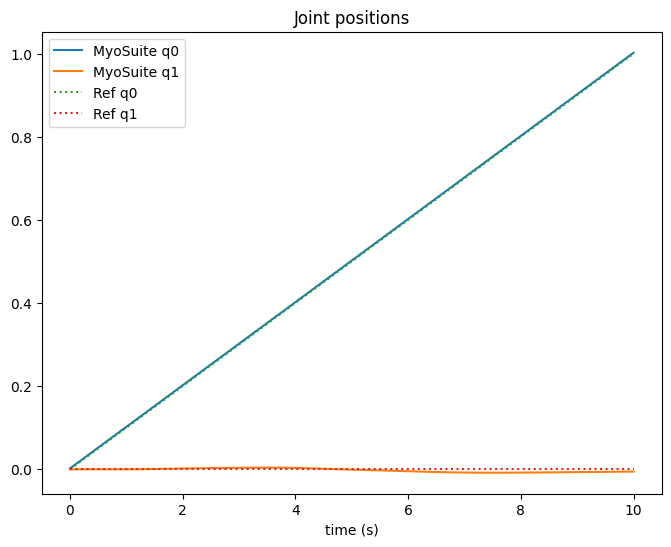

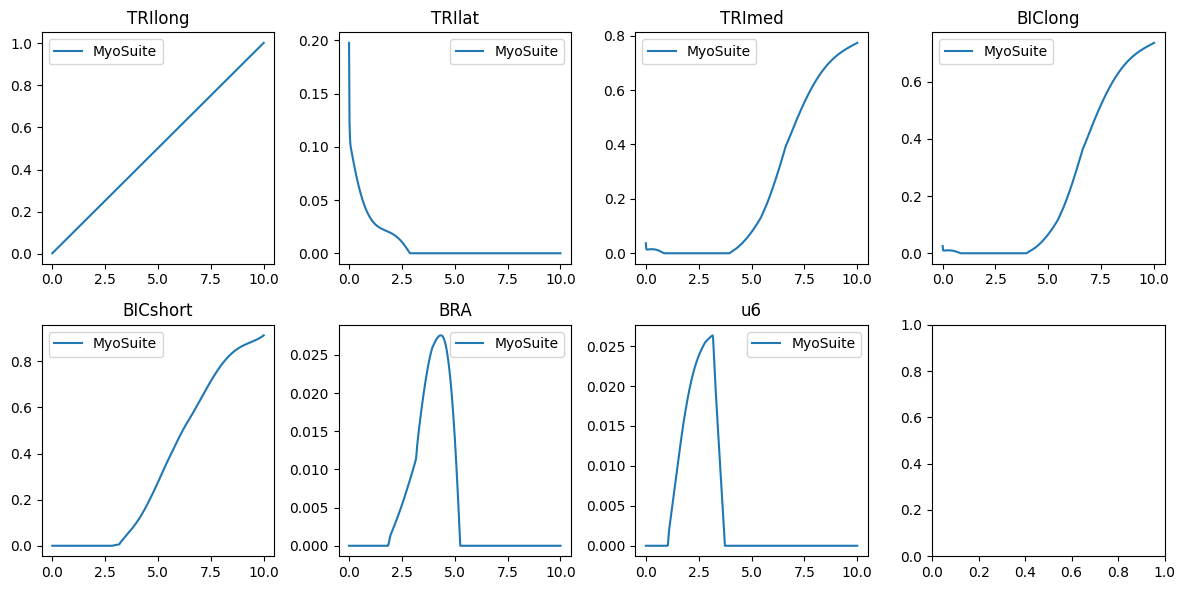

In [12]:
plot_qpos(all_qpos, all_qpos_opensim, traj)
muscle_names = [model1.actuator(i).name for i in range(model0.nu)]
plot_uxxx(all_ctrl, all_ctrl_opensim, muscle_names)


In [13]:
# ---- initializations
model_ref = loader.get_sim(None, 'elbow/myoelbow_2dof6muscles.xml')
data_ref = mujoco.MjData(model_ref) # data for reference trajectory
model_test = loader.get_sim(None, 'elbow/myoelbow_2dof6muscles.xml')
data_test = mujoco.MjData(model_test) # test data for achieved trajectory

camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.distance =  1.1070990185160428
camera.elevation = -10.232281643227267
camera.lookat = np.array([-0.1130067696435806, 0.0815790401272094, 1.0655519045043413])

options_ref = mujoco.MjvOption()
options_ref.flags[:] = 0
options_ref.flags[[1, 22]] = 1
options_ref.geomgroup[2:] = 0

options_test = mujoco.MjvOption()
options_test.flags[:] = 0
options_test.flags[[1, 4, 22]] = 1
options_test.geomgroup[:] = 1

renderer_ref = mujoco.Renderer(model_ref, width=480, height=480)
renderer_ref.scene.flags[:] = 0

renderer_test = mujoco.Renderer(model_test, width=480, height=480)
renderer_test.scene.flags[:] = 0

frames = []
for idx in tqdm(range(traj.shape[0])):
    data_ref.qpos[:2] = [traj[idx, 1], traj[idx, 4]]
    mujoco.mj_step1(model_ref, data_ref)
    data_test.ctrl = all_ctrl[idx, 1:]
    mujoco.mj_step(model_test, data_test)
    if not idx % round(0.3/(model_test.opt.timestep*25)):
        renderer_ref.update_scene(data_ref, camera=camera, scene_option=options_ref)
        frame_ref = renderer_ref.render()
        renderer_test.update_scene(data_test, camera=camera, scene_option=options_test)
        frame_test = renderer_test.render()
        frame_merged = np.append(frame_ref, frame_test, axis=1)
        frames.append(frame_merged)

os.makedirs('videos', exist_ok = True)
output_name = 'videos/myoelbow_freemovement.mp4'
imageio.mimwrite(output_name, frames, fps=1.0 / model_test.opt.timestep)


100%|██████████| 501/501 [00:00<00:00, 1844.15it/s]


In [14]:
display(Video(output_name, embed=True))
